# Gemini API: Working with Charts, Graphs, and Slide Decks

Gemini models are powerful multimodal LLMs that can process both text and image inputs.

This notebook shows how Gemini Flash model is capable of extracting data from various images.


## Setup

### Install the Google GenAI SDK

Install the Google GenAI SDK from [npm](https://www.npmjs.com/package/@google/genai). 

```bash
$ npm install @google/genai
```

### Slides Setup

You will be using images from [Priyanka Vergadia's](https://github.com/priyankavergadia) [GCPSketchnote](https://github.com/priyankavergadia/GCPSketchnote) repository. These pages contain many details that should provide a good benchmark for Gemini's capabilities.

These images are on [Creative Commons Attribution 4.0 International Public License](https://github.com/priyankavergadia/GCPSketchnote/tree/main?tab=License-1-ov-file).


### Setup your API key

You can [create](https://aistudio.google.com/app/apikey) your API key using Google AI Studio with a single click.

Remember to treat your API key like a password. Don't accidentally save it in a notebook or source file you later commit to GitHub. In this notebook we will be storing the API key in a `.env` file. You can also set it as an environment variable or use a secret manager. 

Here's how to set it up in a `.env` file:

```bash
$ touch .env
$ echo "GEMINI_API_KEY=<YOUR_API_KEY>" >> .env
```

:::{.callout-tip}

Another option is to set the API key as an environment variable. You can do this in your terminal with the following command:

```bash
$ export GEMINI_API_KEY="<YOUR_API_KEY>"
```
:::

### Load the API key

To load the API key from the `.env` file, we will use the `dotenv` package. This package loads environment variables from a `.env` file into `process.env`. 

```bash
$ npm install dotenv
```

Then, we can load the API key in our code:


In [2]:
const dotenv = require("dotenv") as typeof import("dotenv");

dotenv.config({
  path: "../.env",
});

const GEMINI_API_KEY = process.env.GEMINI_API_KEY ?? "";
if (!GEMINI_API_KEY) {
  throw new Error("GEMINI_API_KEY is not set in the environment variables");
}
console.log("GEMINI_API_KEY is set in the environment variables");


GEMINI_API_KEY is set in the environment variables


:::{.callout-note}
In our particular case the `.env` is is one directory up from the notebook, hence we need to use `../` to go up one directory. If the `.env` file is in the same directory as the notebook, you can omit it altogether. 

```
│
├── .env
└── examples
    └── Working_with_Charts_Graphs_and_Slide_Decks.ipynb
```
:::


### Initialize SDK Client

With the new SDK, now you only need to initialize a client with you API key (or OAuth if using [Vertex AI](https://cloud.google.com/vertex-ai)). The model is now set in each call.


In [3]:
const google = require("@google/genai") as typeof import("@google/genai");

const ai = new google.GoogleGenAI({ apiKey: GEMINI_API_KEY });


### Select a model

Now select the model you want to use in this guide, either by selecting one in the list or writing it down. Keep in mind that some models, like the 2.5 ones are thinking models and thus take slightly more time to respond (cf. [thinking notebook](../quickstarts/Get_started_thinking.ipynb) for more details and in particular learn how to switch the thiking off).


In [4]:
const tslab = require("tslab") as typeof import("tslab");

const MODEL_ID = "gemini-2.5-flash-preview-05-20";


## Interpreting a single chart


In [5]:
const fs = require("fs") as typeof import("fs");
const path = require("path") as typeof import("path");

const downloadFile = async (url: string, filePath: string) => {
  const response = await fetch(url);
  if (!response.ok) {
    throw new Error(`Failed to download file: ${response.statusText}`);
  }
  fs.mkdirSync(path.dirname(filePath), { recursive: true });
  const buffer = await response.blob();
  const bufferData = Buffer.from(await buffer.arrayBuffer());
  fs.writeFileSync(filePath, bufferData);
};


In [11]:
const CHART_URL =
  "https://storage.googleapis.com/gweb-uniblog-publish-prod/original_images/gemini_final_text_table_amendment_13_12_23.gif";
const chartFilePath = path.join("../assets/examples", "gemini_final_text_table_amendment_13_12_23.gif");
await downloadFile(CHART_URL, chartFilePath);


The image needs to be transformed into a `.jpg`, since `.gif` is not supported by Gemini API at the moment.


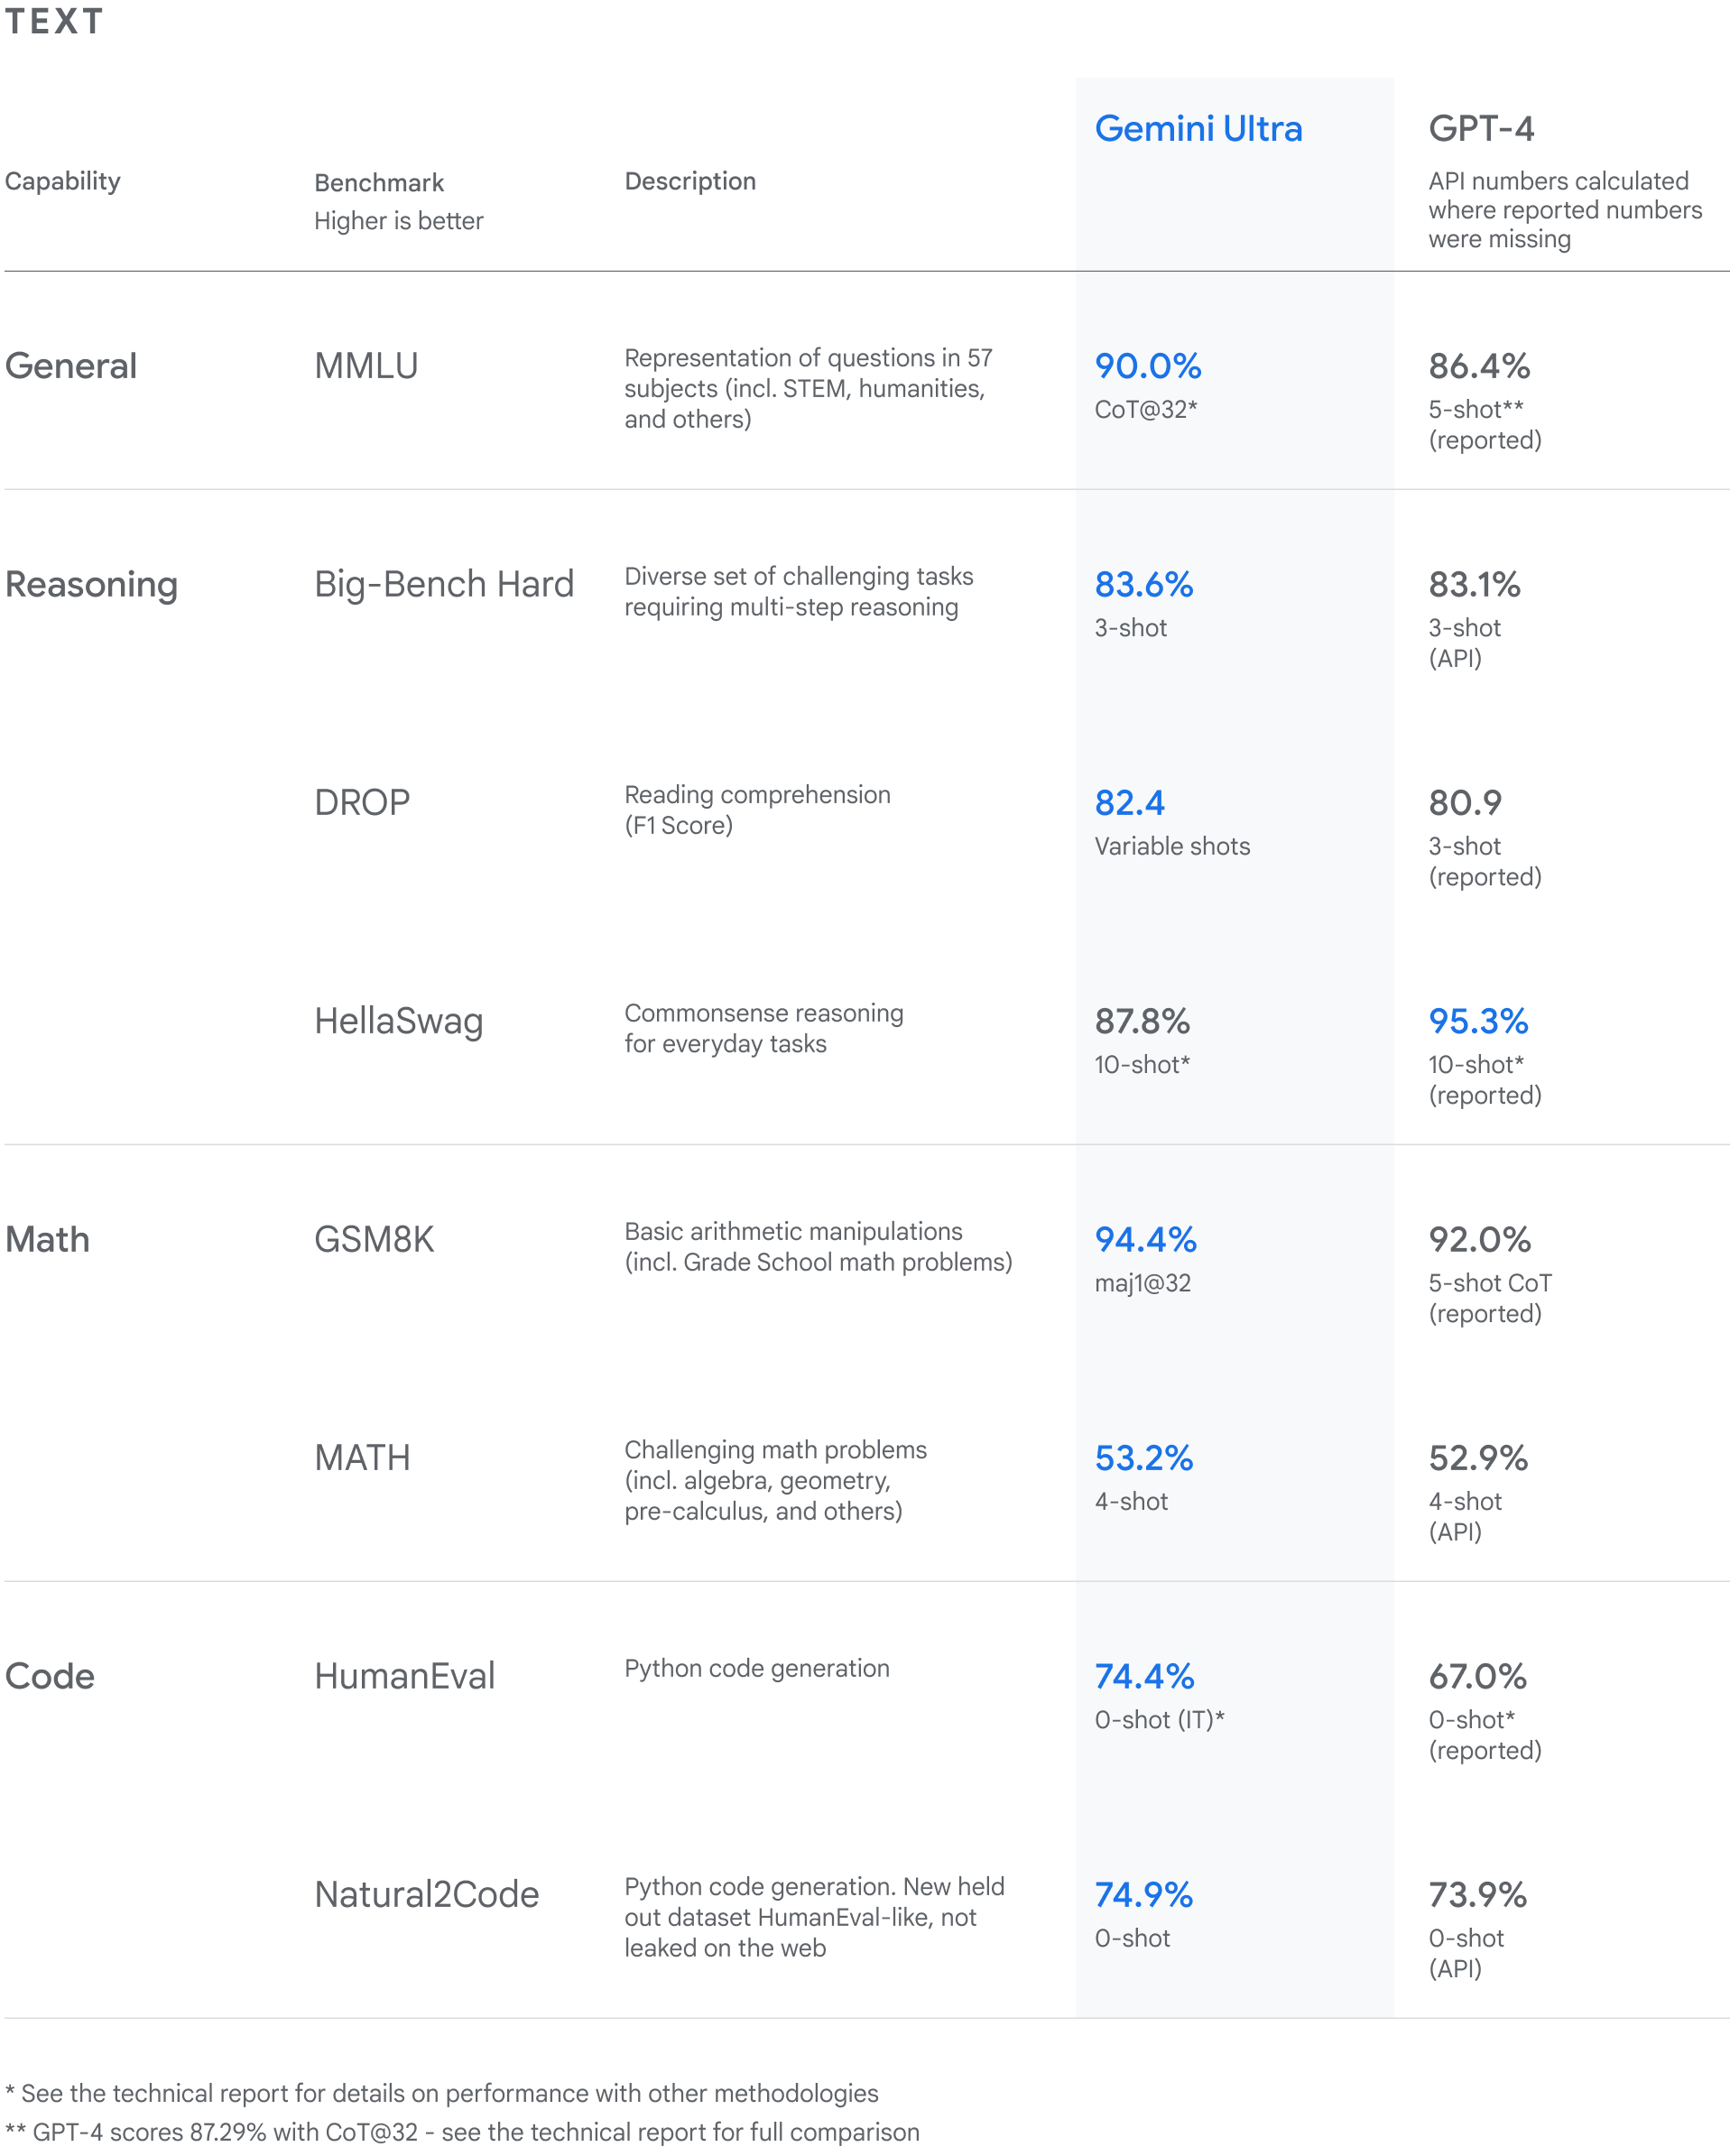

In [ ]:
const canvas = require("canvas") as typeof import("canvas");

const gifToPng = async (gifPath: string, pngPath: string) => {
  const image = await canvas.loadImage(gifPath);
  const pngCanvas = canvas.createCanvas(image.width, image.height);
  const ctx = pngCanvas.getContext("2d");
  ctx.drawImage(image, 0, 0);
  const buffer = pngCanvas.toBuffer("image/png");
  fs.writeFileSync(pngPath, buffer);
};
const pngFilePath = path.join("../assets/examples", "gemini_final_text_table_amendment_13_12_23.png");
await gifToPng(chartFilePath, pngFilePath);
tslab.display.png(fs.readFileSync(pngFilePath));


Now, you will define helper functions for shrinking the image and querying the model with images.


In [20]:
async function shrinkImage(imageBuffer: Buffer, ratio = 2): Promise<Buffer> {
  const image = await canvas.loadImage(imageBuffer);
  const { width } = image;
  const { height } = image;
  const pngCanvas = canvas.createCanvas(width / ratio, height / ratio);
  const ctx = pngCanvas.getContext("2d");
  ctx.drawImage(image, 0, 0, width / ratio, height / ratio);
  return pngCanvas.toBuffer("image/png");
}


In [23]:
async function generateContentFromImage(prompt: string, imagePaths: string[]): Promise<string> {
  const imageBuffers = await Promise.all(
    imagePaths.map(async (imagePath) => {
      const buffer = fs.readFileSync(imagePath);
      return shrinkImage(buffer);
    })
  );
  const response = await ai.models.generateContent({
    model: MODEL_ID,
    contents: [
      prompt,
      ...imageBuffers.map((buffer) => google.createPartFromBase64(buffer.toString("base64"), "image/png")),
    ],
  });
  return response.text ?? "";
}


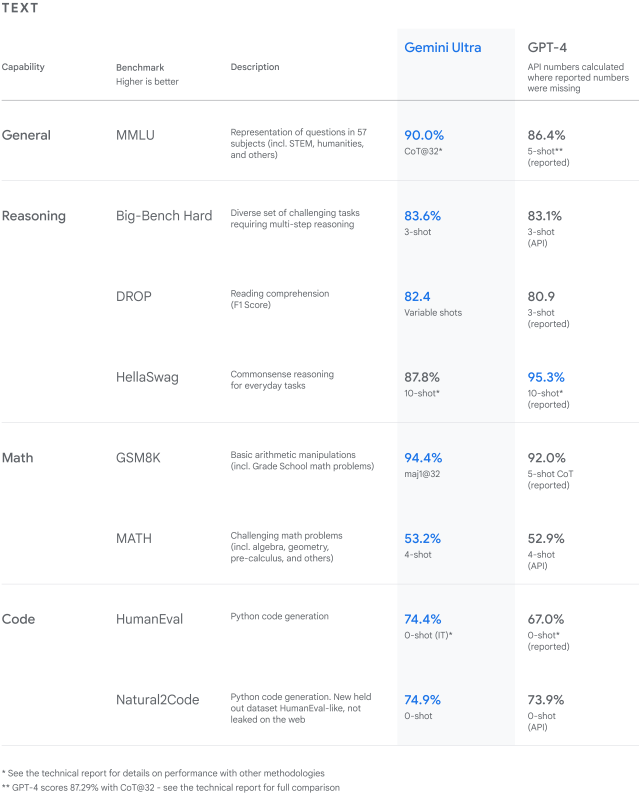

In [ ]:
tslab.display.png(await shrinkImage(fs.readFileSync(pngFilePath), 3));


Now, let's see how the LLM can handle the following query.


In [ ]:
const response = await generateContentFromImage(
  "You are a tool that interprets tables. Which model (Gemini Ultra or GPT-4) is better in the 'Math' category in MATH benchmark?",
  [pngFilePath]
);
tslab.display.markdown(response);


Based on the table:

*   For the 'Math' category, under the 'MATH' benchmark:
    *   **Gemini Ultra** scores **53.2%**
    *   **GPT-4** scores **52.9%**

Therefore, **Gemini Ultra** is better in the 'Math' category in the MATH benchmark.

## Extracting information from a single slide

You will use the model to extract information from a single slide. In this case graph describing pub/sub. It is not a complicated usecase, however it will showcase, how you can call the model.

You need to download an example chart.


In [25]:
const SLIDE_URL = "https://raw.githubusercontent.com/priyankavergadia/GCPSketchnote/refs/heads/main/images/pubsub.png";
const slideFilePath = path.join("../assets/examples", "pubsub.png");
await downloadFile(SLIDE_URL, slideFilePath);


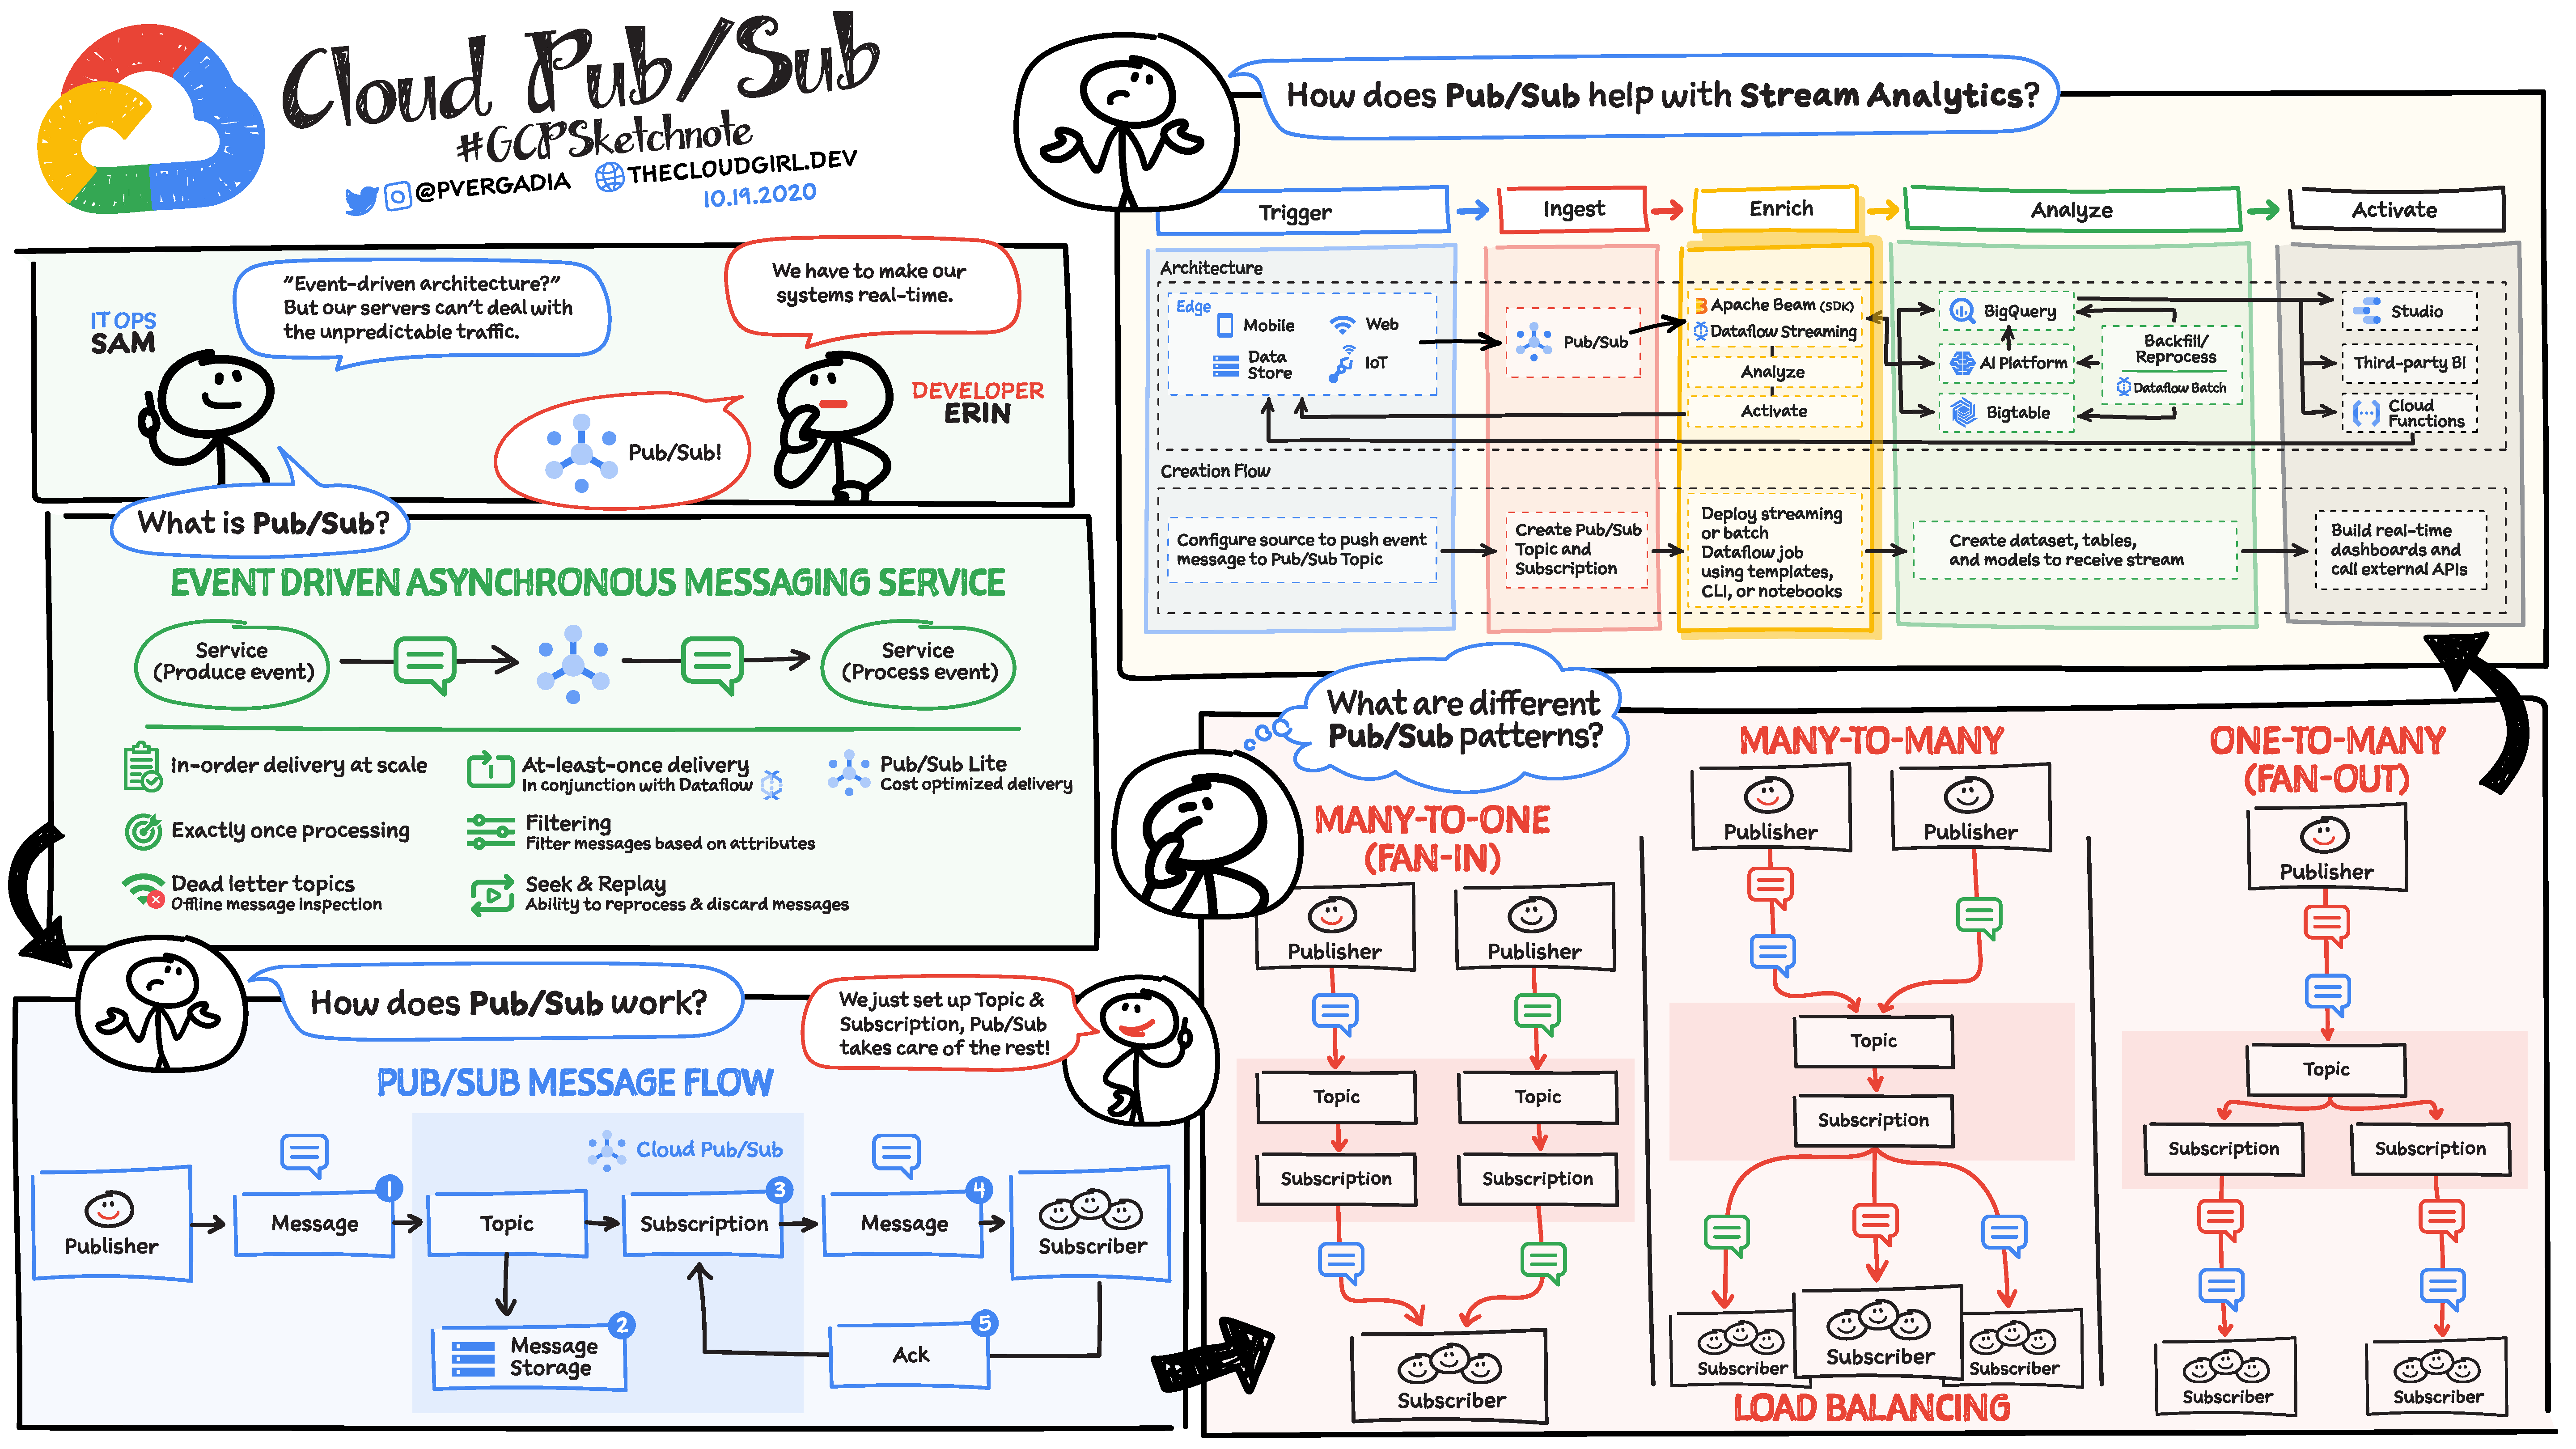

In [27]:
tslab.display.png(fs.readFileSync(slideFilePath));


Start with something simple:


In [29]:
const summary = await generateContentFromImage("Describe the image in 5 sentences.", [slideFilePath]);
tslab.display.markdown(summary);


This detailed sketchnote vividly explains Google Cloud Pub/Sub, an "event-driven asynchronous messaging service." It illustrates how Pub/Sub helps systems manage unpredictable traffic and achieve real-time capabilities by facilitating communication between different components. The core message flow is depicted, showing Publishers sending messages to Topics, which are then delivered to Subscribers via Subscriptions, with mechanisms for message storage and acknowledgment. Furthermore, the infographic outlines how Pub/Sub integrates into stream analytics pipelines, encompassing stages like triggering, ingesting, enriching, analyzing, and activating data. Finally, it presents various Pub/Sub patterns, including Many-to-One (Fan-In), Many-to-Many (Load Balancing), and One-to-Many (Fan-Out), showcasing its versatility for different messaging architectures.

You can also use it to extract information from specific parts of the image:


In [30]:
const negativeResponse = await generateContentFromImage(
  "Explain the diffrent pub sub patters using the image. Ignore the rest.",
  [slideFilePath]
);
tslab.display.markdown(negativeResponse);


Based on the "What are different Pub/Sub patterns?" section of the image, here are the explanations for each pattern:

1.  **MANY-TO-ONE (FAN-IN)**
    *   **Description:** In this pattern, multiple publishers send messages, and these messages are consumed by a single subscriber.
    *   **How it works (as per image):** Two different publishers send their messages to two different topics. Each topic has its own subscription. However, both subscriptions are configured to deliver messages to a single subscriber. This means messages from multiple sources (publishers via their respective topics) "fan in" to be processed by one consumer.

2.  **MANY-TO-MANY (with Load Balancing)**
    *   **Description:** This pattern involves multiple publishers sending messages to a single topic, and these messages are then distributed among multiple subscribers for processing, achieving load balancing.
    *   **How it works (as per image):** Two distinct publishers send their messages to the *same* topic. From this single topic, there is one subscription. This single subscription then delivers messages to multiple subscribers, indicated by the message splitting from the subscription to the individual subscribers. The "Load Balancing" label indicates that these messages are distributed among the available subscribers to share the processing workload.

3.  **ONE-TO-MANY (FAN-OUT)**
    *   **Description:** In this pattern, a single publisher sends messages, and these messages are delivered to multiple, independent subscribers.
    *   **How it works (as per image):** A single publisher sends messages to a single topic. From this topic, there are multiple, distinct subscriptions. Each of these subscriptions then delivers the message to its own, independent subscriber. This means that a message published once is "fanned out" and received by every subscriber that has a subscription to that topic.

## Slide Decks

While most models can receive only a handful images at once, The Gemini Flash model is able to receive up to 3,600 images in a single request. This means that most slide decks can be passed without any splitting to the model.

In this case you will use the LLM to create a set of questions that check the knowledge of GCP products:


In [35]:
const SLIDE_URLS = [
  "https://raw.githubusercontent.com/priyankavergadia/GCPSketchnote/refs/heads/main/images/BigQuery.png",
  "https://raw.githubusercontent.com/priyankavergadia/GCPSketchnote/refs/heads/main/images/CloudRun.png",
  "https://raw.githubusercontent.com/priyankavergadia/GCPSketchnote/refs/heads/main/images/GCS.png",
  "https://raw.githubusercontent.com/priyankavergadia/GCPSketchnote/refs/heads/main/images/analytics.png",
];
const slideFilePaths = await Promise.all(
  SLIDE_URLS.map(async (url) => {
    const fileName = path.basename(url);
    const filePath = path.join("../assets/examples", fileName);
    await downloadFile(url, filePath);
    return filePath;
  })
);
const questions = await generateContentFromImage(
  "Your job is to create a set of questions to check knowledge of various gcp products. Write for each image the topic and example question.",
  slideFilePaths
);
tslab.display.markdown(questions);


Here's a set of questions to check knowledge of various GCP products based on the provided sketchnotes:

---

## BigQuery Sketchnote Questions

| Topic                    | Example Question                                                                                                   |
| :----------------------- | :----------------------------------------------------------------------------------------------------------------- |
| **Core Definition**      | What type of service is BigQuery primarily described as?                                                           |
| **Operational Model**    | BigQuery is described as "serverless." What does this imply about infrastructure management for the user?            |
| **Key Features**         | Name one unique feature of BigQuery that allows users to perform machine learning directly within the database.      |
| **Pricing Model**        | True or False: BigQuery charges for both storage and queries, but offers free storage for public datasets.         |
| **Security Features**    | What security control does BigQuery offer that allows customers to manage their own encryption keys?                 |
| **Data Ingestion**       | In a typical BigQuery use case, what GCP service is often used to process and enrich streaming data before ingestion? |
| **Data Types Supported** | Can BigQuery analyze both batch and streaming data?                                                                |

---

## Cloud Run Sketchnote Questions

| Topic                       | Example Question                                                                                           |
| :-------------------------- | :--------------------------------------------------------------------------------------------------------- |
| **Core Purpose**            | What is Cloud Run primarily designed for, in terms of application deployment and scaling?                  |
| **Invocation Methods**      | Name two common ways to invoke or trigger a Cloud Run service.                                             |
| **Scalability Feature**     | What is a key feature of Cloud Run that allows it to optimize costs by shutting down when not in use?      |
| **Pricing Model**           | How is Cloud Run primarily priced?                                                                         |
| **Security/Access Control** | What GCP service is used to manage identity and access for Cloud Run services?                             |
| **Application Type**        | What type of application packaging is required before deploying to Cloud Run?                              |
| **Use Case Eligibility**    | Can Cloud Run be used for a simple website backend or a microservice, according to the use case example?   |

---

## Cloud Storage Sketchnote Questions

| Topic                  | Example Question                                                                                                    |
| :--------------------- | :------------------------------------------------------------------------------------------------------------------ |
| **Core Attributes**    | What are the three main characteristics of Cloud Storage as described in the definition?                            |
| **Data Organization**  | How are objects typically organized within Cloud Storage?                                                           |
| **Storage Classes**    | Which Cloud Storage class is designed for data accessed approximately once a month, with a 30-day minimum storage duration? |
| **Pricing Factors**    | True or False: All Cloud Storage classes have the same cost for data retrieval, regardless of access frequency.     |
| **Encryption Options** | Beyond default encryption at rest, what two options does Cloud Storage provide for customers to manage their own encryption keys? |
| **Data Transfer**      | For large-scale, on-premise data transfers to Cloud Storage, what physical hardware option is available?           |
| **Use Case (Archiving)** | If you need to store data for long-term archiving with infrequent access, which Cloud Storage class would be most cost-effective? |

---

## Scalable Data Analytics Pipeline Sketchnote Questions

| Topic                      | Example Question                                                                                               |
| :------------------------- | :------------------------------------------------------------------------------------------------------------- |
| **Data Ingestion**         | Name two GCP services that can be used for capturing streaming data in a data analytics pipeline.              |
| **Data Processing**        | Which GCP service is recommended for reliable streaming and batch data processing within the pipeline?         |
| **Data Storage (Lake/WH)** | What two primary GCP services are used for storing data in a data lake or data warehousing scenario within this pipeline? |
| **Analysis Engine**        | What is the primary analysis engine depicted in this scalable data analytics pipeline?                         |
| **Advanced Analytics/ML**  | Name two tools or services that can be used for advanced analytics or machine learning on data processed in this pipeline. |
| **Orchestration**          | What GCP service is depicted for fully managed workflow orchestration based on Apache Airflow?                  |
| **Data Lineage/Metadata**  | What service is available for managing metadata and tracking lineage of datasets across the pipeline?          |

## Summary

The Gemini API's great capabilities in processing images such as charts, graphs, and slide decks highlights the power of multimodal LLMs. Thanks to the model's ability to read and understand these visual elements, everyone can unlock great ideas, simplify tasks, and save valuable time.

Imagine the impact of leveraging Gemini API to implement AI solutions that describe surroundings for the disabled community, making technology more inclusive and accessible to all.

This is just one of the exciting possibilities. Now, it's your turn to explore Gemini further!
